In [1]:
import pandas as pd
path = "/Users/kike/Downloads/mall/Mall_Customers.csv"



In [3]:
d = pd.read_csv(path)
d.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# dimensiones del data set
d.shape

(200, 5)

In [7]:
#Tipos de datos
d.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [9]:
# Explorar estadisticas del dataset mall
d.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
#ver los nulos
d.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

K=2 → inercia: 181363.60 | silhouette: 0.2969
K=3 → inercia: 106348.37 | silhouette: 0.4676
K=4 → inercia: 73679.79 | silhouette: 0.4932
K=5 → inercia: 44448.46 | silhouette: 0.5539
K=6 → inercia: 37233.81 | silhouette: 0.5398
K=7 → inercia: 30241.34 | silhouette: 0.5288
K=8 → inercia: 25036.42 | silhouette: 0.4548
K=9 → inercia: 21916.79 | silhouette: 0.4561
K=10 → inercia: 20072.07 | silhouette: 0.4411


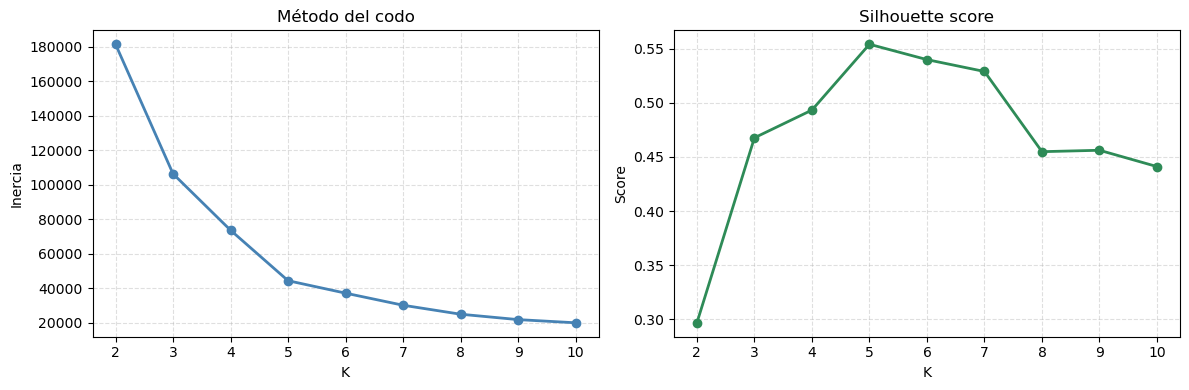

In [15]:
#Obteniendo el numero optimo de clusters
#usaremos Anual income y Spending Score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

path = "/Users/kike/Downloads/mall/Mall_Customers.csv"
df = pd.read_csv(path)

# Variables para clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Método del codo + silhouette
inercias = []
silhouettes = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"K={k} → inercia: {km.inertia_:.2f} | silhouette: {silhouette_score(X, labels):.4f}")

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Método del codo')
ax1.set_xlabel('K')
ax1.set_ylabel('Inercia')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.plot(rango_k, silhouettes, marker='o', color='seagreen', linewidth=2)
ax2.set_title('Silhouette score')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import mplcursors

# K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Grupo'] = kmeans.fit_predict(X)

# Nombres descriptivos por grupo (los asignamos después de ver los centroides)
print("=== CENTROIDES ===")
centroides = kmeans.cluster_centers_
for i, c in enumerate(centroides):
    print(f"Grupo {i} → Ingreso: {c[0]:.1f}k | Spending Score: {c[1]:.1f}")

print("\n=== CONTEO POR GRUPO ===")
print(df['Grupo'].value_counts().sort_index())

=== CENTROIDES ===
Grupo 0 → Ingreso: 55.3k | Spending Score: 49.5
Grupo 1 → Ingreso: 86.5k | Spending Score: 82.1
Grupo 2 → Ingreso: 25.7k | Spending Score: 79.4
Grupo 3 → Ingreso: 88.2k | Spending Score: 17.1
Grupo 4 → Ingreso: 26.3k | Spending Score: 20.9

=== CONTEO POR GRUPO ===
Grupo
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


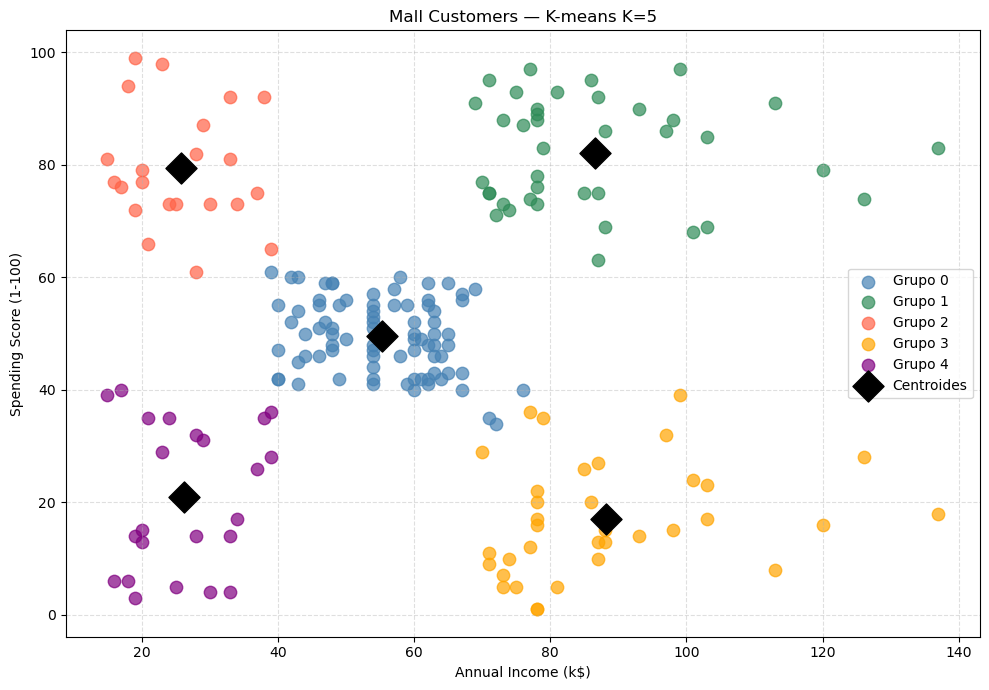

In [19]:
#Graficamos
colores = {0:'steelblue', 1:'seagreen', 2:'tomato', 3:'orange', 4:'purple'}

fig, ax = plt.subplots(figsize=(10, 7))

for grupo, datos in df.groupby('Grupo'):
    ax.scatter(datos['Annual Income (k$)'], datos['Spending Score (1-100)'],
               color=colores[grupo], s=80, label=f'Grupo {grupo}', alpha=0.7)

# Centroides
ax.scatter(centroides[:,0], centroides[:,1],
           color='black', s=250, marker='D', label='Centroides', zorder=5)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Mall Customers — K-means K=5')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
for i, c in enumerate(centroides):
    print(f"Grupo {i} → Ingreso: {c[0]:.1f}k | Spending Score: {c[1]:.1f}")

Grupo 0 → Ingreso: 55.3k | Spending Score: 49.5
Grupo 1 → Ingreso: 86.5k | Spending Score: 82.1
Grupo 2 → Ingreso: 25.7k | Spending Score: 79.4
Grupo 3 → Ingreso: 88.2k | Spending Score: 17.1
Grupo 4 → Ingreso: 26.3k | Spending Score: 20.9
